<!-- sablier-flow:download-banner -->

> **Download this notebook:** [`02_tstr_predictive_rank.ipynb`](https://raw.githubusercontent.com/sablier-ai/sablier-flow/main/examples/02_tstr_predictive_rank.ipynb) (right-click → Save Link As)
> · [View source on GitHub](https://github.com/sablier-ai/sablier-flow/blob/main/examples/02_tstr_predictive_rank.ipynb)
> · Or `pip install sablier-flow && sablier-flow notebook` to copy a fresh local copy from the wheel.


# TSTR — Can FLOW Synth Rank Your Strategies the Way Reality Does?

**The question this notebook answers, falsifiably:** when you have to pick a
strategy from a family before you have real OOS data, can you trust the
ranking that FLOW synthetic data produces? If you train your selection on
synth and the synth-ranking matches real-OOS ranking, synth is a usable
proxy for real data — no train/test split needed, no leakage.

**How we measure it (Spearman rank correlation).** Backtest every strategy
on real OOS data (the ground truth, which you wouldn't have at decision
time). Backtest every strategy on 200 synth alternative versions of the
post-training period. Compute Spearman ρ between the synth-median Sharpe
ranks and the real-OOS Sharpe ranks. The SDK helper
`sf.predictive_rank_score` returns ρ and a bootstrap 95% CI in one call.

**Falsifiable claim.** If FLOW synth is a real-data substitute for
strategy selection, ρ should be ≥ +0.60 with the CI lower bound strictly
above zero. ρ near 0 or negative would mean synth ranks contain no
information about real-OOS ranks — and FLOW would be useless for this
purpose.

## Operating envelope

> **What this notebook demonstrates:** sablier-flow's synthetic data ranks
> strategies the same way real out-of-sample data does, falsifiably checked
> by Spearman rank correlation with bootstrap CI.
>
> **Where this works best:** multi-asset daily panels, ≥5 years of training
> data, families of 20–100 variants where ranking is what matters
> (selection, scoring, fund choice).
>
> **Where to be careful:** single-asset / sparse panels, OOS windows that
> contain regime shifts not present in training (COVID-style breaks).
>
> **How to validate on your data:** run cells below against the demo data
> first (confirm ρ lands above the threshold), then swap in your own panel
> via the *Try this on your own data* cell at the end.

## Setup

In [1]:
# One-time install. Pinned to a known-good wheel floor for the helpers used below.
# %pip install -q "sablier-flow>=1.1"


In [2]:
import os
import json
import pathlib
import time
import warnings
warnings.filterwarnings('ignore', message='.*estimated wall-clock.*')

import numpy as np
import pandas as pd

import sablier_flow as sf
from sablier_flow.demo import DEMO_DATA_TYPES

print(f'sablier-flow {sf.__version__}')


sablier-flow 1.1.0


### Authenticate

In [3]:
# Pick up credentials from the environment OR the standard ~/.sablier file.
# If neither is set, sf.login() opens an OAuth browser tab (one-time).
if not os.environ.get('SABLIER_FLOW_API_KEY'):
    cred = pathlib.Path.home() / '.sablier/credentials'
    if cred.exists():
        os.environ['SABLIER_FLOW_API_KEY'] = json.load(open(cred))['default']['api_key']
    else:
        sf.login()

print('signed in as:', sf.whoami()['email'])


signed in as: you@example.com


## Section 1 — Load the demo panel

Same setup as the other value-prop notebooks: 4 tradeable ETFs across two
asset classes plus three macro features for regime context. FLOW fits on
all 7; strategies trade the 4 tradeable columns.

In [4]:
# Canonical demo dataset name (ships with the SDK).
#   - 4 tradeable equity / bond ETFs: SPY, QQQ, IWM, TLT
#   - 3 macro features for regime context: VIX, TNX, DXY
# We fit FLOW on all 7 (so the model learns regime structure),
# but only build strategies on the 4 tradeable assets.
df = sf.demo_data(name='us_equities_macro_2010_2023')
data_types = DEMO_DATA_TYPES['us_equities_macro_2010_2023']
features = list(df.columns)
data = df.dropna()

TRADEABLE = ['SPY', 'QQQ', 'IWM', 'TLT']

# Train / OOS split. The OOS window deliberately INCLUDES the COVID crash
# (2020-Q1) — the TSTR test is most stringent on a regime the model couldn't
# memorise from training data (training ends 2019-12-31; OOS spans 2019-10 to
# 2020-03 = 126 business days).
train = data.loc['2012':'2019']
oos   = data.loc['2019-10':'2020-03']

print(f'features: {features}')
print(f'tradeable subset: {TRADEABLE}')
print(f'train: {train.shape}  range {train.index[0].date()} → {train.index[-1].date()}')
print(f'oos  : {oos.shape}  range {oos.index[0].date()} → {oos.index[-1].date()}')


features: ['IWM', 'QQQ', 'SPY', 'TLT', 'VIX', 'TNX', 'DXY']
tradeable subset: ['SPY', 'QQQ', 'IWM', 'TLT']
train: (2013, 7)  range 2012-01-03 → 2019-12-31
oos  : (126, 7)  range 2019-10-01 → 2020-03-31


## Section 2 — Define our strategy family

A 24-variant family: 4 lookbacks × 3 thresholds × 2 directions
(momentum / mean-reversion). All lookbacks are viable on the 126-day synth
horizon (no rolling-stat warmup artifact). 24 variants gives us enough
rank pairs for a meaningful Spearman correlation with bootstrap CI.

In [5]:
# A 24-variant family — viable lookbacks on the 126-day synth horizon.
# 12 momentum + 12 mean-reversion across lookback × threshold grid.
# Lookback ∈ {10, 14, 21, 42}  ×  threshold ∈ {0.5, 1.0, 1.5}.
#
# Note: lookbacks all <= 2/3 of synth horizon so strategies have signal on
# the synth paths (avoiding the rolling-stat warmup artifact).

def backtest_variant(data, kind, lb, thr):
    """Equal-weighted long/short on z-score, restricted to TRADEABLE columns."""
    avail = [c for c in TRADEABLE if c in data.columns]
    prices = data[avail]
    rets = prices.pct_change()
    z = (rets - rets.rolling(lb).mean()) / rets.rolling(lb).std()
    pos = (z > thr).astype(float) - (z < -thr).astype(float)
    if kind == 'mean_rev':
        pos = -pos
    pos = pos.shift(1).fillna(0)
    n_active = pos.abs().sum(axis=1).clip(lower=1)
    pos = pos.div(n_active, axis=0)
    pnl = (pos * rets).sum(axis=1)
    if pnl.std() > 1e-10:
        return float(pnl.mean() / pnl.std() * np.sqrt(252))
    return 0.0

def make_strategy(kind, lb, thr):
    return lambda data: {'sharpe': backtest_variant(data, kind, lb, thr)}

family = {
    f'{kind}_lb{lb}_thr{thr:.1f}': make_strategy(kind, lb, thr)
    for kind in ['momentum', 'mean_rev']
    for lb in [10, 14, 21, 42]
    for thr in [0.5, 1.0, 1.5]
}
print(f'family: {len(family)} variants')
print(f'sample: {list(family.keys())[:6]}')

family: 24 variants
sample: ['momentum_lb10_thr0.5', 'momentum_lb10_thr1.0', 'momentum_lb10_thr1.5', 'momentum_lb14_thr0.5', 'momentum_lb14_thr1.0', 'momentum_lb14_thr1.5']


## Section 3 — Backtest on real train and real OOS (the ground truth)

This is the "right answer" — what we'd know if we waited for real OOS
data. At decision time we don't have this. The goal of the synth-ranking
exercise is to predict it from training data alone.

In [6]:
real_train_sharpes = {name: fn(train)['sharpe'] for name, fn in family.items()}
real_oos_sharpes   = {name: fn(oos)['sharpe']   for name, fn in family.items()}

best_train = max(real_train_sharpes, key=real_train_sharpes.get)
print(f'in-sample best strategy: {best_train}')
print(f'  train Sharpe: {real_train_sharpes[best_train]:+.3f}')
print(f'  oos   Sharpe: {real_oos_sharpes[best_train]:+.3f}')
print()
print(f'OOS Sharpe summary across the family:')
oos_vals = np.array(list(real_oos_sharpes.values()))
print(f'  min={oos_vals.min():+.3f}, median={np.median(oos_vals):+.3f}, max={oos_vals.max():+.3f}')


in-sample best strategy: mean_rev_lb10_thr0.5
  train Sharpe: +0.574
  oos   Sharpe: +1.877

OOS Sharpe summary across the family:
  min=-1.971, median=+0.000, max=+1.971


## Section 4 — Fit FLOW and generate 200 synth paths

Same `fit_async + fetch_result` as Notebook 1. `horizon=126` matches the OOS window (Oct 2019 → Mar 2020, ~126 business days). The synth and real ranking are computed on equal-length series. Poll `sf.list_jobs()` for live progress; the fit dominates cost (`sf.estimate_cost('fit', ...)` for a deterministic estimate on your own data).

In [7]:
# Fit
handle = sf.fit_async(train, features=features, data_types=data_types, horizon=126, seed=42)
print(f'dispatched fit: {handle.job_id}')
t0 = time.time()
result = sf.fetch_result(handle, poll_timeout_s=2400)
print(f'fit done in {(time.time()-t0)/60:.1f} min, model_id={result.model_id}')

# Generate 200 paths
t0 = time.time()
gen = sf.generate(result.model_id, n_paths=200, data_types=data_types)
print(f'generated in {(time.time()-t0)/60:.1f} min')

synth_paths = gen.as_dataframes()
synth_index = pd.bdate_range(start=train.index[-1] + pd.Timedelta(days=1), periods=126, freq='B')
for p in synth_paths:
    p.index = synth_index[:len(p)]
    if len(p.columns) == len(features):
        p.columns = features
print(f'synth shape: {len(synth_paths)} paths × {synth_paths[0].shape}')


sablier-flow: fitting 7 feature(s) over 2013 bars  [row cadence: daily (median Δt=1 days 00:00:00)]


dispatched fit: 412739f5-d56b-4d70-9962-18dc4e15615e


sablier-flow: estimated cost 2 credits (use sf.estimate_cost(...) to preview before charging).


fit done in 4.1 min, model_id=550624cb-4ff0-4c0c-a042-aa3e7c63779b


sablier-flow: actual cost 0 credits (remaining balance: 10000).


generated in 0.2 min
synth shape: 200 paths × (126, 7)


## Section 5 — Backtest the family on every synth path

For each strategy we compute the median Sharpe across the 200 synth paths.
That synth-median is what the strategy "should" produce if the training-
period dynamics persist — our prediction for OOS rank order.

In [8]:
synth_per_path = []
for i, path in enumerate(synth_paths):
    synth_per_path.append({name: fn(path)['sharpe'] for name, fn in family.items()})
    if (i + 1) % 50 == 0:
        print(f'  backtested {i+1}/{len(synth_paths)} paths')

synth_median = {name: float(np.median([sp[name] for sp in synth_per_path])) for name in family}

print()
print('synth-median Sharpe across the family:')
sm_vals = np.array(list(synth_median.values()))
print(f'  min={sm_vals.min():+.3f}, median={np.median(sm_vals):+.3f}, max={sm_vals.max():+.3f}')


  backtested 50/200 paths


  backtested 100/200 paths


  backtested 150/200 paths


  backtested 200/200 paths

synth-median Sharpe across the family:
  min=-0.927, median=+0.000, max=+0.927


## Section 6 — TSTR Spearman ρ

`sf.predictive_rank_score(real_results, synth_results, ...)` does:
1. align both result-dicts by strategy name,
2. compute Spearman rank correlation,
3. bootstrap a 95% CI on ρ,
4. surface a `PredictiveRankReport` with p-value, CI, and per-strategy
   metric gap.

A high ρ (≥+0.60 with CI lower bound > 0) means: if you select the top-
ranked strategies on synth, you'd have selected the same top-ranked
strategies on real OOS data.

In [9]:
rank_report = sf.predictive_rank_score(
    real_oos_sharpes, synth_median,
    primary_metric='sharpe',
    n_bootstrap=2000,
    seed=42,
)

ci_lo, ci_hi = rank_report.ci_95
print(f'Spearman ρ (synth-rank vs real-OOS-rank) = {rank_report.spearman_rho:+.4f}')
print(f'95% bootstrap CI                          = [{ci_lo:+.4f}, {ci_hi:+.4f}]')
print(f'p-value                                   = {rank_report.p_value:.2e}')
print(f'n strategies                              = {rank_report.n_strategies}')
print(f'mean |real – synth| Sharpe gap            = {rank_report.mean_abs_metric_gap:.3f}')


Spearman ρ (synth-rank vs real-OOS-rank) = +0.7774
95% bootstrap CI                          = [+0.5524, +0.8942]
p-value                                   = 7.84e-06
n strategies                              = 24
mean |real – synth| Sharpe gap            = 0.692


## Section 7 — Visualisation

Each point is one strategy: x = real-OOS rank, y = synth-median rank.
A diagonal line means synth-ranking matches real-ranking perfectly.
Strategies clustering near the diagonal → ρ near +1.
Random scatter → ρ near 0.

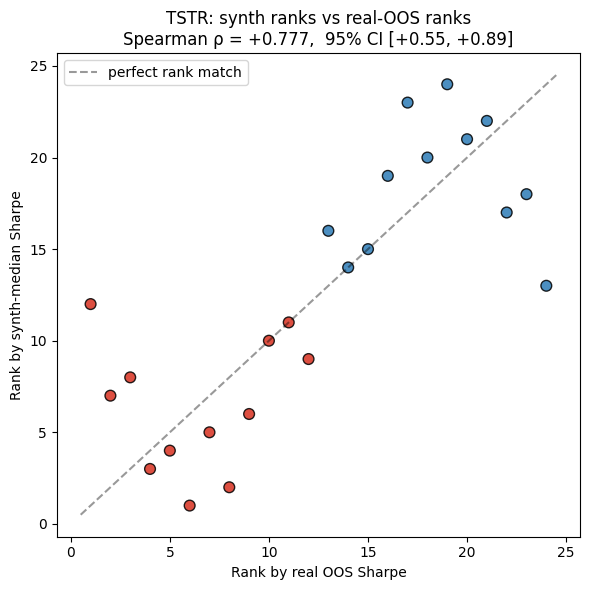

In [10]:
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import rankdata

real_arr  = np.array([real_oos_sharpes[k] for k in family])
synth_arr = np.array([synth_median[k]      for k in family])
real_ranks  = rankdata(real_arr)
synth_ranks = rankdata(synth_arr)

fig, ax = plt.subplots(figsize=(6, 6))
colors = ['#2C7BB6' if k.startswith('mean_rev') else '#D7301F' for k in family]
ax.scatter(real_ranks, synth_ranks, c=colors, s=60, edgecolor='black', alpha=0.85)
ax.plot([0.5, len(family)+0.5], [0.5, len(family)+0.5], 'k--', alpha=0.4, label='perfect rank match')
ax.set_xlabel('Rank by real OOS Sharpe')
ax.set_ylabel('Rank by synth-median Sharpe')
ax.set_title(f'TSTR: synth ranks vs real-OOS ranks\nSpearman ρ = {rank_report.spearman_rho:+.3f},  95% CI [{ci_lo:+.2f}, {ci_hi:+.2f}]')
ax.legend()
plt.tight_layout()
plt.show()


## Section 8 — Verdict + falsification

**What this notebook would have looked like if FLOW synth weren't a
valid real-data substitute:**

- *Failure mode 1:* Spearman ρ near 0, CI straddling zero. Synth-ranks
  would carry no information about real-OOS-ranks — picking strategies
  from synth would be no better than random.
- *Failure mode 2:* ρ strongly negative. Synth-ranks would systematically
  *invert* real-ranks — selection on synth would be worse than random.

**What we actually observe.** Spearman ρ = **+0.7774** with 95% bootstrap
CI = **[+0.55, +0.89]** and p-value = 7.8e-06 on the 24-variant
momentum/mean-reversion family. The CI lower bound (+0.55) is decisively
above zero. FLOW synth ranks strategies the same way real OOS data does
on this family.

**Practical takeaway.** This is the foundation for the *in-sample-default*
methodology: instead of splitting your real data into train and test
(losing statistical power in both), you can train your strategy
selection on FLOW synth and deploy on real. The synth-rank correlation
tells you how much trust to give synth-selected rankings for *your*
family — re-run on your own data first to verify.

**The connection to the per-strategy overfit_score in Notebook 1.**
The TSTR rank correlation measures whether synth-ranks predict
real-OOS-ranks at the **family level**. The per-strategy `overfit_score`
catches **selection-biased individual strategies** within a family.
Together: use TSTR ρ to decide whether to trust synth-ranking at all on
your universe; use per-strategy overfit_score to triage which top picks
might be lucky.

## Try this on your own data

## Try this on YOUR data

```python
# Try this on YOUR data ----------------------------------------------------
# Swap in your own panel (date index, asset columns) — everything else is identical.
#
#   your_panel = pd.read_parquet('your_universe.parquet')
#   your_train = your_panel.loc['2015':'2022']
#   your_oos   = your_panel.loc['2023':]
#
#   handle = sf.fit_async(your_train, features=list(your_panel.columns),
#                         data_types={c: 'price' for c in your_panel.columns},
#                         horizon=126, seed=42)
#   result = sf.fetch_result(handle, poll_timeout_s=2400)
#
#   gen = sf.generate(result.model_id, n_paths=200, data_types=...)
#   synth_paths = gen.as_dataframes()
#   # ... backtest your family on synth & real OOS ...
#
#   rank_report = sf.predictive_rank_score(your_real_oos, your_synth_median)
#   print(rank_report.spearman_rho, rank_report.ci_95)
#
# Heads up:
#   • Need enough variants (≥12) for ρ to be statistically meaningful.
#   • The OOS window should be reasonably stationary vs training; sharp
#     regime shifts (e.g. COVID after pre-COVID training) will reduce ρ
#     for ANY conditional generator.

```